In [2]:
begin
    import Pkg
    Pkg.activate(Base.current_project())
	
    using IntrinsicDecoherence
end

  Activating project at `~/Documents/Devs/IntrinsicDecoherence`


In [3]:
begin
	using PyPlot
	using LaTeXStrings
	ioff()
	rc("text", usetex = true)
end

# Intrinsic decoherence dynamics in the three-coupled harmonic oscillators interaction
### Companion plotting notebook
___
Authors: **_Alejandro R. Urzúa & Héctor M. Moya Cessa_**

Instituto Nacional de Astrofísica, Óptica y Electrónica

([arurz@inaoep.mx](mailto:arurz@inaoep.mx), [hmmc@inaoep.mx](mailto:hmmc@inaoep.mx))

Developer: AR. Urzúa (2021)

 [![License: MIT](https://img.shields.io/badge/License-MIT-yellow.svg)](https://opensource.org/licenses/MIT)
___
#### 1. Description

In this notebook you will encounter the plots who are reported in the nextcomming paper selftitled above. It relies on the developed Julia package [Intrinsic Decoherence](https://github.com/rurz/IntrinsicDecoherence), hosted at Github. This particular notebook is finded at `/IntrinsicDecoherence/notebooks`. Because this is a Binder linked notebook you will change the parameters and play with the behaviour of the equations described below.

#### 2. Theory

Go to the bottom of the notebook

#### 3. Technical

In the Github repositoy you will find the source code at `/IntrinsicDecoherence/src/Funcs.jl`. There, the functions titled `exv_a`, `exv_a₁` and  `exv_a₂` will do the tricks. They are the implemented Julia functions reported in the upcoming paper. You can take a look.

For anyone of the functions, their variable dependence are `exv_a(ω, λ, g, γ, α, t)`.
___

## Initial problem

The principal idea is to solve the mean value evolution

$$\newcommand{\braket}[1]{\left\langle #1\right\rangle}\begin{equation}
	\braket{\hat{A}}  = e^{-\gamma t}\sum_{k=0}^{\infty}\frac{ (\gamma t)^k}{k!} \left\langle \psi_{k} | \hat{A} | \psi_{k}\right\rangle,
\end{equation}$$

giving that the $k$-th element of the wavefunction $\psi$ is given by

$$\newcommand{\ket}[1]{\left|#1\right\rangle}\newcommand{\bra}[1]{\left\langle #1\right|}\begin{equation}
    \rho_{k}=\ket{\psi_{k}}\bra{\psi_k}, \qquad \ket{\psi_{k}}=e^{-\mathrm{i} k\frac{\hat{H}}{\gamma}}\ket{\psi(0)},
\end{equation}$$

with the Hamiltonian of the system defined as

$$\newcommand{\op}[1]{\hat{#1}}\begin{equation}
\begin{aligned}
    \op{H} = \omega\left(\op{a}_{1}^{\dagger}\op{a}_{1} + \op{a}_{2}^{\dagger}\op{a}_{2} + \op{a}_{3}^{\dagger}\op{a}_{3}\right) + \lambda\left(\op{a}_{1}^{\dagger}\op{a}_{2} + \op{a}_{2}^{\dagger}\op{a}_{1}\right)
    + g\left[\op{a}_{3}\left(\op{a}_{1}^{\dagger}+\op{a}_{2}^{\dagger}\right)+\op{a}_{3}^{\dagger}(\op{a}_{1}+\op{a}_{2})\right].
\end{aligned}
\end{equation}$$

## Solution

The solution we find for the $k$-th element of the wavefunction $\psi$ is given by

$$\newcommand{\op}[1]{\hat{#1}}\newcommand{\mi}{\mathrm{i}}\begin{align*}
    \ket{\psi_{k}} &= \op{R}_{12}^{\dagger}\op{R}_{2}^{\dagger}\,e^{-\mi k\frac{\op{H}_{2}}{\gamma}}\ket{\alpha\cos\theta}_{1}\ket{\alpha\cos\phi\sin\theta}_{2}\ket{-\alpha\sin\phi\sin\theta}_{3}\\
    &= \op{R}_{12}^{\dagger}\op{R}_{2}^{\dagger}\ket{e^{-\frac{\mi k}{\gamma}\Omega_{2}}\alpha\cos\theta}_{1}\ket{e^{-\frac{\mi k}{\gamma}\omega_{-}}\alpha\cos\phi\sin\theta}_{2}\ket{-e^{-\frac{\mi k}{\gamma}\Omega}\alpha\sin\phi\sin\theta}_{3},
\end{align*}$$

with $\gamma$ the decay parameter, $\theta = \pi/4$, and 
$$\begin{equation*}
    2\phi = \arctan\left(\frac{2\sqrt{2}g}{\omega_{+}-\omega}\right),
\end{equation*}$$ where g is the coupling strength, and $\omega_{\pm} = \omega \pm \lambda$.

In [5]:
begin
	const α = 4
	const ω = 4
	const λ = 0.5
end;

## Case 1. $\gamma = 10$

In [6]:
# For γ = 10
begin
	t_list = range(0, stop = 70, length = 1000)
	
	texv1_a = [exv_a(ω, λ, 0.1, 10, α, t_list[τ]) for τ in 1:length(t_list)]
	texv1_a1 = [exv_a₁(ω, λ, 0.1, 10, α, t_list[τ]) for τ in 1:length(t_list)]
	texv1_a2 = [exv_a₂(ω, λ, 0.1, 10, α, t_list[τ]) for τ in 1:length(t_list)]
	
	texv2_a = [exv_a(ω, λ, 0.5, 10, α, t_list[τ]) for τ in 1:length(t_list)]
	texv2_a1 = [exv_a₁(ω, λ, 0.5, 10, α, t_list[τ]) for τ in 1:length(t_list)]
	texv2_a2 = [exv_a₂(ω, λ, 0.5, 10, α, t_list[τ]) for τ in 1:length(t_list)]
	
	texv3_a = [exv_a(ω, λ, 1, 10, α, t_list[τ]) for τ in 1:length(t_list)]
	texv3_a1 = [exv_a₁(ω, λ, 1, 10, α, t_list[τ]) for τ in 1:length(t_list)]
	texv3_a2 = [exv_a₂(ω, λ, 1, 10, α, t_list[τ]) for τ in 1:length(t_list)]
end;

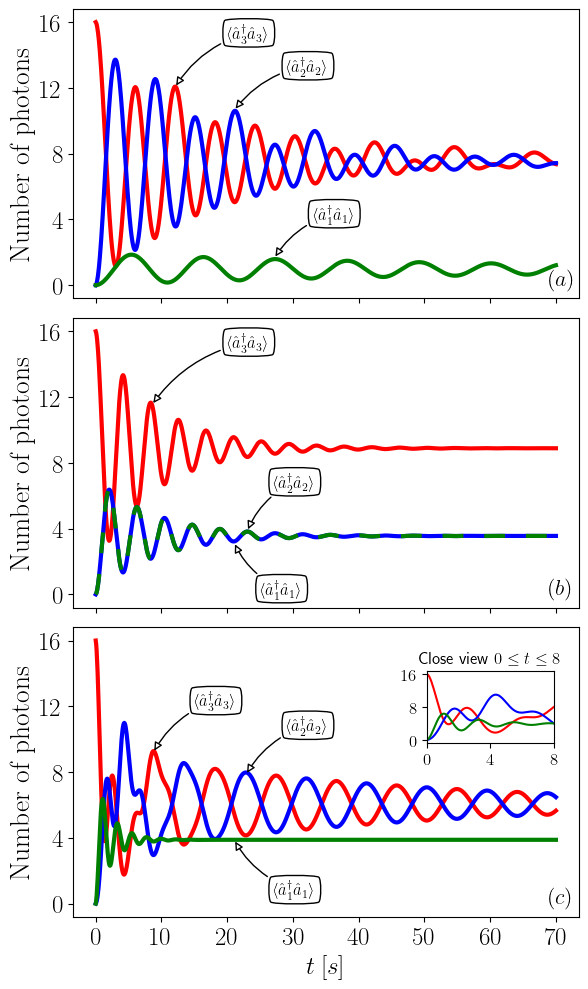

In [10]:
begin
	figs, (axs1, axs2, axs3) = subplots(3,1, figsize = (6,10), sharex = true)
	
	axs1.plot(t_list, real(texv1_a1), "r", lw = 3, label = L"\langle \hat{a}_{1}^{\dagger}\hat{a}_{1} \rangle")
	axs1.plot(t_list, real(texv1_a2), "b", lw = 3, label = L"\langle \hat{a}_{2}^{\dagger}\hat{a}_{2} \rangle")
	axs1.plot(t_list, real(texv1_a), "g", lw = 3, label = L"\langle \hat{a}_{3}^{\dagger}\hat{a}_{3} \rangle")
	axs2.plot(t_list, real(texv2_a1), "r", lw = 3, label = L"\langle \hat{a}_{1}^{\dagger}\hat{a}_{1} \rangle")
	axs2.plot(t_list, real(texv2_a2), "b", ms = 4, lw = 3, label = L"\langle \hat{a}_{2}^{\dagger}\hat{a}_{2} \rangle")
	axs2.plot(t_list, real(texv2_a), "g", linestyle = (0, (5, 5)), lw = 3, label = L"\langle \hat{a}_{3}^{\dagger}\hat{a}_{3} \rangle")
	
	axs3.plot(t_list, real(texv3_a1), "r", lw = 3, label = L"\langle \hat{a}_{1}^{\dagger}\hat{a}_{1} \rangle")
	axs3.plot(t_list, real(texv3_a2), "b", lw = 3, label = L"\langle \hat{a}_{2}^{\dagger}\hat{a}_{2} \rangle")
	axs3.plot(t_list, real(texv3_a), "g", lw = 3, label = L"\langle \hat{a}_{3}^{\dagger}\hat{a}_{3} \rangle")

	axs1.text(69, 0, L"(a)", fontsize=16)
	axs2.text(69, 0, L"(b)", fontsize=16)
	axs3.text(69, 0, L"(c)", fontsize=16)
	
	axs1.set_yticks([0, 4, 8, 12, 16])
	axs2.set_yticks([0, 4, 8, 12, 16])
	axs3.set_yticks([0, 4, 8, 12, 16])
	
	axins = axs3.inset_axes([0.7, 0.6, 0.25, 0.25])
	axins.plot(t_list, real(texv3_a1), "r")
	axins.plot(t_list, real(texv3_a2), "b")
	axins.plot(t_list, real(texv3_a), "g")
	axins.set_xlim([0,8])
	axins.set_title(L"Close view $0 \leq t \leq 8$", fontsize = 12)
	setp(axins.get_xticklabels(), fontsize = 12)
	setp(axins.get_yticklabels(), fontsize = 12)
	axins.set_yticks([0,8,16])
	axins.set_xticks([0,4,8])
	
	axs1.set_ylabel(L"\textrm{Number of photons}", fontsize = 20)
	setp(axs1.get_xticklabels(), fontsize = 18)
	setp(axs1.get_yticklabels(), fontsize = 18)
	#axs1.legend(fontsize = 13)
	axs1.annotate(L"\langle \hat{a}_{3}^{\dagger}\hat{a}_{3} \rangle", xy=(12, 12), xytext=(20, 15), size= 12,
		bbox=Dict("boxstyle"=>"round4", "fc"=>"w"),
            arrowprops=Dict("arrowstyle"=>"-|>",
                        "connectionstyle"=>"arc3,rad=0.2",
                                  "fc"=>"w")
	)
	axs1.annotate(L"\langle \hat{a}_{2}^{\dagger}\hat{a}_{2} \rangle", xy=(21, 10.6), xytext=(29, 13), size= 12,
		bbox=Dict("boxstyle"=>"round4", "fc"=>"w"),
            arrowprops=Dict("arrowstyle"=>"-|>",
                        "connectionstyle"=>"arc3,rad=0.2",
                                  "fc"=>"w")
	)
	axs1.annotate(L"\langle \hat{a}_{1}^{\dagger}\hat{a}_{1} \rangle", xy=(27.1, 1.6), xytext=(33, 4), size= 12,
		bbox=Dict("boxstyle"=>"round4", "fc"=>"w"),
            arrowprops=Dict("arrowstyle"=>"-|>",
                        "connectionstyle"=>"arc3,rad=0.2",
                                  "fc"=>"w")
	)
	
	axs2.set_ylabel(L"\textrm{Number of photons}", fontsize = 20)
	setp(axs2.get_xticklabels(), fontsize = 18)
	setp(axs2.get_yticklabels(), fontsize = 18)
	#axs2.legend(fontsize = 13)
	axs2.annotate(L"\langle \hat{a}_{3}^{\dagger}\hat{a}_{3} \rangle", xy=(8.5, 11.5), xytext=(20, 15), size= 12,
		bbox=Dict("boxstyle"=>"round4", "fc"=>"w"),
            arrowprops=Dict("arrowstyle"=>"-|>",
                        "connectionstyle"=>"arc3,rad=0.2",
                                  "fc"=>"w")
	)
	axs2.annotate(L"\langle \hat{a}_{2}^{\dagger}\hat{a}_{2} \rangle", xy=(23, 3.8), xytext=(27, 6.5), size= 12,
		bbox=Dict("boxstyle"=>"round4", "fc"=>"w"),
            arrowprops=Dict("arrowstyle"=>"-|>",
                        "connectionstyle"=>"arc3,rad=0.2",
                                  "fc"=>"w")
	)
	axs2.annotate(L"\langle \hat{a}_{1}^{\dagger}\hat{a}_{1} \rangle", xy=(21, 3.2), xytext=(25, 0), size= 12,
		bbox=Dict("boxstyle"=>"round4", "fc"=>"w"),
            arrowprops=Dict("arrowstyle"=>"-|>",
                        "connectionstyle"=>"arc3,rad=-0.2",
                                  "fc"=>"w")
	)
	
	axs3.set_xlabel(L"t\; [s]", fontsize = 18)
	axs3.set_ylabel(L"\textrm{Number of photons}", fontsize = 20)
	setp(axs3.get_xticklabels(), fontsize = 18)
	setp(axs3.get_yticklabels(), fontsize = 18)
	#axs3.legend(fontsize = 13)
	axs3.annotate(L"\langle \hat{a}_{3}^{\dagger}\hat{a}_{3} \rangle", xy=(8.7, 9.15), xytext=(15, 12), size= 12,
		bbox=Dict("boxstyle"=>"round4", "fc"=>"w"),
            arrowprops=Dict("arrowstyle"=>"-|>",
                        "connectionstyle"=>"arc3,rad=0.2",
                                  "fc"=>"w")
	)
	axs3.annotate(L"\langle \hat{a}_{2}^{\dagger}\hat{a}_{2} \rangle", xy=(22.8, 7.8), xytext=(29, 10.5), size= 12,
		bbox=Dict("boxstyle"=>"round4", "fc"=>"w"),
            arrowprops=Dict("arrowstyle"=>"-|>",
                        "connectionstyle"=>"arc3,rad=0.2",
                                  "fc"=>"w")
	)
	axs3.annotate(L"\langle \hat{a}_{1}^{\dagger}\hat{a}_{1} \rangle", xy=(21, 3.92), xytext=(27, 0.5), size= 12,
		bbox=Dict("boxstyle"=>"round4", "fc"=>"w"),
            arrowprops=Dict("arrowstyle"=>"-|>",
                        "connectionstyle"=>"arc3,rad=-0.2",
                                  "fc"=>"w")
	)
	
	tight_layout()

	#savefig("γ10_sp.pdf", dpi = 300)
	#savefig("γ10_sp.png", dpi = 300)
end

## Case 2. $\gamma = 100$

In [8]:
# For γ = 100
begin
	t_lisT = range(0, stop = 7, length = 500)
	
	texV1_a = [exv_a(ω, λ, 0.1, 100, α, t_lisT[τ]) for τ in 1:length(t_lisT)]
	texV1_a1 = [exv_a₁(ω, λ, 0.1, 100, α, t_lisT[τ]) for τ in 1:length(t_lisT)]
	texV1_a2 = [exv_a₂(ω, λ, 0.1, 100, α, t_lisT[τ]) for τ in 1:length(t_lisT)]
	
	texV2_a = [exv_a(ω, λ, 0.5, 100, α, t_lisT[τ]) for τ in 1:length(t_lisT)]
	texV2_a1 = [exv_a₁(ω, λ, 0.5, 100, α, t_lisT[τ]) for τ in 1:length(t_lisT)]
	texV2_a2 = [exv_a₂(ω, λ, 0.5, 100, α, t_lisT[τ]) for τ in 1:length(t_lisT)]
	
	texV3_a = [exv_a(ω, λ, 1, 100, α, t_lisT[τ]) for τ in 1:length(t_lisT)]
	texV3_a1 = [exv_a₁(ω, λ, 1, 100, α, t_lisT[τ]) for τ in 1:length(t_lisT)]
	texV3_a2 = [exv_a₂(ω, λ, 1, 100, α, t_lisT[τ]) for τ in 1:length(t_lisT)]
end;

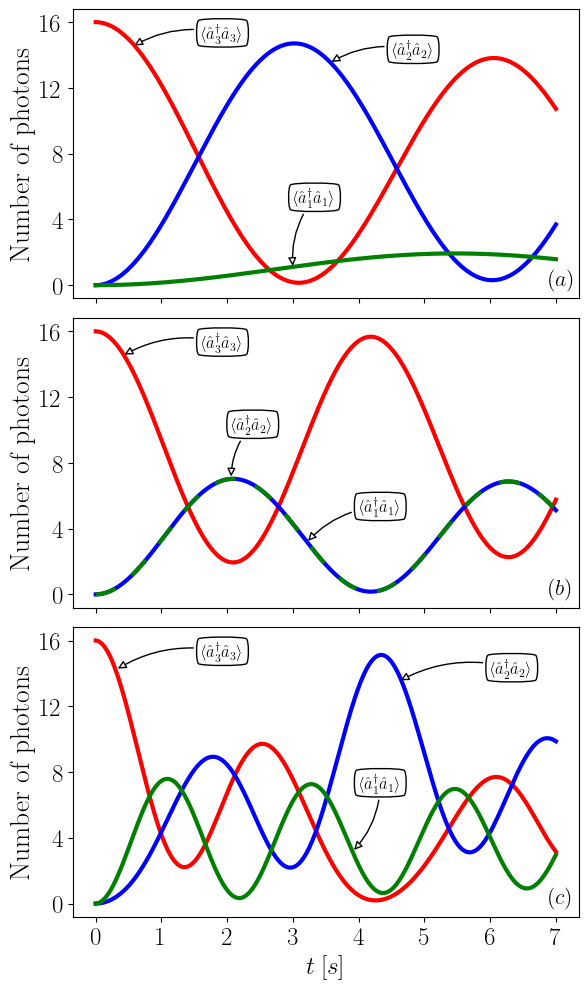

In [9]:
begin
	figS, (axS1, axS2, axS3) = subplots(3,1, figsize = (6,10), sharex = true)
	
	axS1.plot(t_lisT, real(texV1_a1), "r", lw = 3, label = L"\langle \hat{a}_{1}^{\dagger}\hat{a}_{1} \rangle")
	axS1.plot(t_lisT, real(texV1_a2), "b", lw = 3, label = L"\langle \hat{a}_{2}^{\dagger}\hat{a}_{2} \rangle")
	axS1.plot(t_lisT, real(texV1_a), "g", lw = 3, label = L"\langle \hat{a}_{3}^{\dagger}\hat{a}_{3} \rangle")
	
	axS2.plot(t_lisT, real(texV2_a1), "r", lw = 3, label = L"\langle \hat{a}_{1}^{\dagger}\hat{a}_{1} \rangle")
	axS2.plot(t_lisT, real(texV2_a2), "b", ms = 3, lw = 3, label = L"\langle \hat{a}_{2}^{\dagger}\hat{a}_{2} \rangle")
	axS2.plot(t_lisT, real(texV2_a), "g", linestyle = (0, (5, 5)), lw = 3, label = L"\langle \hat{a}_{3}^{\dagger}\hat{a}_{3} \rangle")
	
	axS3.plot(t_lisT, real(texV3_a1), "r", lw = 3, label = L"\langle \hat{a}_{1}^{\dagger}\hat{a}_{1} \rangle")
	axS3.plot(t_lisT, real(texV3_a2), "b", lw = 3, label = L"\langle \hat{a}_{2}^{\dagger}\hat{a}_{2} \rangle")
	axS3.plot(t_lisT, real(texV3_a), "g", lw = 3, label = L"\langle \hat{a}_{3}^{\dagger}\hat{a}_{3} \rangle")
	
	axS1.text(6.9, 0, L"(a)", fontsize=16)
	axS2.text(6.9, 0, L"(b)", fontsize=16)
	axS3.text(6.9, 0, L"(c)", fontsize=16)
	
	axS1.set_yticks([0, 4, 8, 12, 16])
	axS2.set_yticks([0, 4, 8, 12, 16])
	axS3.set_yticks([0, 4, 8, 12, 16])
	
	axS1.set_ylabel(L"\textrm{Number of photons}", fontsize = 20)
	setp(axS1.get_xticklabels(), fontsize = 18)
	setp(axS1.get_yticklabels(), fontsize = 18)
	#axS1.legend(fontsize = 13)
	axS1.annotate(L"\langle \hat{a}_{3}^{\dagger}\hat{a}_{3} \rangle", xy=(0.55, 14.5), xytext=(1.6, 15), size= 12,
		bbox=Dict("boxstyle"=>"round4", "fc"=>"w"),
            arrowprops=Dict("arrowstyle"=>"-|>",
                        "connectionstyle"=>"arc3,rad=0.2",
                                  "fc"=>"w")
	)
	axS1.annotate(L"\langle \hat{a}_{2}^{\dagger}\hat{a}_{2} \rangle", xy=(3.55, 13.5), xytext=(4.5, 14), size= 12,
		bbox=Dict("boxstyle"=>"round4", "fc"=>"w"),
            arrowprops=Dict("arrowstyle"=>"-|>",
                        "connectionstyle"=>"arc3,rad=0.2",
                                  "fc"=>"w")
	)
	axS1.annotate(L"\langle \hat{a}_{1}^{\dagger}\hat{a}_{1} \rangle", xy=(3, 1), xytext=(3, 5), size= 12,
		bbox=Dict("boxstyle"=>"round4", "fc"=>"w"),
            arrowprops=Dict("arrowstyle"=>"-|>",
                        "connectionstyle"=>"arc3,rad=0.2",
                                  "fc"=>"w")
	)
	
	
	axS2.set_ylabel(L"\textrm{Number of photons}", fontsize = 20)
	setp(axS2.get_xticklabels(), fontsize = 18)
	setp(axS2.get_yticklabels(), fontsize = 18)
	#axS2.legend(fontsize = 13)
	axS2.annotate(L"\langle \hat{a}_{3}^{\dagger}\hat{a}_{3} \rangle", xy=(0.4, 14.5), xytext=(1.6, 15), size= 12,
		bbox=Dict("boxstyle"=>"round4", "fc"=>"w"),
            arrowprops=Dict("arrowstyle"=>"-|>",
                        "connectionstyle"=>"arc3,rad=0.2",
                                  "fc"=>"w")
	)
	axS2.annotate(L"\langle \hat{a}_{2}^{\dagger}\hat{a}_{2} \rangle", xy=(2.06, 7), xytext=(2.06, 10), size= 12,
		bbox=Dict("boxstyle"=>"round4", "fc"=>"w"),
            arrowprops=Dict("arrowstyle"=>"-|>",
                        "connectionstyle"=>"arc3,rad=0.2",
                                  "fc"=>"w")
	)
	axS2.annotate(L"\langle \hat{a}_{1}^{\dagger}\hat{a}_{1} \rangle", xy=(3.2, 3.13), xytext=(4, 5), size= 12,
		bbox=Dict("boxstyle"=>"round4", "fc"=>"w"),
            arrowprops=Dict("arrowstyle"=>"-|>",
                        "connectionstyle"=>"arc3,rad=0.2",
                                  "fc"=>"w")
	)
	
	axS3.set_xlabel(L"t\; [s]", fontsize = 18)
	axS3.set_ylabel(L"\textrm{Number of photons}", fontsize = 20)
	setp(axS3.get_xticklabels(), fontsize = 18)
	setp(axS3.get_yticklabels(), fontsize = 18)
	#axS3.legend(fontsize = 13)
	axS3.annotate(L"\langle \hat{a}_{3}^{\dagger}\hat{a}_{3} \rangle", xy=(0.3, 14.2), xytext=(1.6, 15), size= 12,
		bbox=Dict("boxstyle"=>"round4", "fc"=>"w"),
            arrowprops=Dict("arrowstyle"=>"-|>",
                        "connectionstyle"=>"arc3,rad=0.2",
                                  "fc"=>"w")
	)
	axS3.annotate(L"\langle \hat{a}_{2}^{\dagger}\hat{a}_{2} \rangle", xy=(4.6, 13.5), xytext=(6, 14), size= 12,
		bbox=Dict("boxstyle"=>"round4", "fc"=>"w"),
            arrowprops=Dict("arrowstyle"=>"-|>",
                        "connectionstyle"=>"arc3,rad=0.2",
                                  "fc"=>"w")
	)
	axS3.annotate(L"\langle \hat{a}_{1}^{\dagger}\hat{a}_{1} \rangle", xy=(3.9, 3.14), xytext=(4, 7), size= 12,
		bbox=Dict("boxstyle"=>"round4", "fc"=>"w"),
            arrowprops=Dict("arrowstyle"=>"-|>",
                        "connectionstyle"=>"arc3,rad=-0.2",
                                  "fc"=>"w")
	)
	
	tight_layout()
	
	#savefig("γ100_sp.pdf", dpi = 300)
	#savefig("γ100_sp.png", dpi = 300)
end

___
The aim is to solve the Hamiltonian for the three-coupled harmonic oscillators

$$\hat{H} = \omega\left(\hat{a}_{1}^{\dagger}\hat{a}_{1} + \hat{a}_{2}^{\dagger}\hat{a}_{2} + \hat{a}_{3}^{\dagger}\hat{a}_{3}\right) + \lambda\left(\hat{a}_{1}^{\dagger}\hat{a}_{2} + \hat{a}_{2}^{\dagger}\hat{a}_{1}\right)+ g\left[\hat{a}_{3}\left(\hat{a}_{1}^{\dagger}+\hat{a}_{2}^{\dagger}\right)+\hat{a}_{3}^{\dagger}(\hat{a}_{1}+\hat{a}_{2})\right],$$

under the Milburn's schema of intrinsic decoherence 

$$\dot{\rho}=\gamma \left(e^{-\mathrm{i}\frac{\hat{H}}{\gamma}}\rho e^{\mathrm{i}\frac{\hat{H}}{\gamma}}- \rho\right).$$

After a series expansion on the $\rho$ equation, and a diagonalization of the Hamiltonian $\hat{H}$, we find the analytical expresions for the photon number evolution $\langle\hat{a}_{i}^{\dagger}\hat{a}_{i}\rangle$ on each of the oscillators when the initial condition is $|\psi(0)\rangle = |0\rangle|\alpha\rangle_{1}|0\rangle_{2}$. The expression are, for the oscillator $\hat{a}$

$$ \langle\hat{a}_{3}^{\dagger}\hat{a}_{3}\rangle = \frac{1}{4}|\alpha|^{2}\left[1 + \left(\cos^{4}\phi + \sin^{4}\phi\right) + 2\sin^{2}\phi\cos^{2}\phi\cos\left(\frac{k}{\gamma}\left(\Omega-\Omega_{2}\right)\right) + 2\cos^{2}\phi\cos\left(\frac{k}{\gamma}\left(\omega_{-}-\Omega_{2}\right)\right)+ 2\sin^{2}\phi\cos\left(\frac{k}{\gamma}\left(\omega_{-}-\Omega\right)\right)\right],$$

for the oscillator $\hat{a}_{1}$

$$\langle\hat{a}_{1}^{\dagger}\hat{a}_{1}\rangle = \frac{1}{4}|\alpha|^{2}\times\\ 
\left(1 + \frac{1}{4}\left(3+\cos\left(4\phi\right)\right) + e^{-\gamma t}\left[\left\{e^{\gamma t e^{i\frac{\Omega-\Omega_{2}}{\gamma}}}+e^{\gamma t e^{-i\frac{\Omega-\Omega_{2}}{\gamma}}}\right\}\cos^{2}\phi\sin^{2}\phi+\left\{e^{\gamma t e^{i\frac{\omega_{-}-\Omega_{2}}{\gamma}}}+e^{\gamma t e^{-i\frac{\omega_{-}-\Omega_{2}}{\gamma}}}\right\}\cos^{2}\phi + \left\{e^{\gamma t e^{i\frac{\omega_{-}-\Omega}{\gamma}}}+e^{\gamma t e^{-i\frac{\omega_{-}-\Omega}{\gamma}}}\right\}\sin^{2}\phi\right]\right),$$

and for the oscillator $hat{a}_{2}$

$$\langle\hat{a}_{2}^{\dagger}\hat{a}_{2}\rangle = \frac{1}{4}|\alpha|^{2}\times\\ 
\left(1 + \frac{1}{4}\left(3+\cos\left(4\phi\right)\right) + e^{-\gamma t}\left[\left\{e^{\gamma t e^{i\frac{\Omega-\Omega_{2}}{\gamma}}}+e^{\gamma t e^{-i\frac{\Omega-\Omega_{2}}{\gamma}}}\right\}\cos^{2}\phi\sin^{2}\phi-\left\{e^{\gamma t e^{i\frac{\omega_{-}-\Omega_{2}}{\gamma}}}+e^{\gamma t e^{-i\frac{\omega_{-}-\Omega_{2}}{\gamma}}}\right\}\cos^{2}\phi - \left\{e^{\gamma t e^{i\frac{\omega_{-}-\Omega}{\gamma}}}+e^{\gamma t e^{-i\frac{\omega_{-}-\Omega}{\gamma}}}\right\}\sin^{2}\phi\right]\right).$$

For the complete details on the calculations, go to the full paper.